C:\Users\malih  ezekiel lah\pyPhysChem



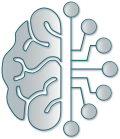

**Start at:** Tuesday 25 November 2025, 20:59:26  
**Hostname:** DESKTOP-P2P20DL (Windows)

<p style="text-align: center"><img width="800px" src="./config/svg/pyPhysChemBanner.svg" style="margin-left:auto; margin-right:auto"/></p>

In [1]:
import os
import sys

print(os.getcwd())
cwd0 = './config/'
sys.path.append(cwd0)

import visualID_Eng as vID
from visualID_Eng import fg,bg,hl,color
vID.init(cwd0)

import tools4pyPhysChem as t4pPC

#cancel the "last show-up" behaviour of Jupyter notebooks
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

__author__ = "Thierry Leininger, LCPQ (CNRS-UT3 lab, Toulouse, France)"

 # Harmonic Oscillator

## Introduction

<div class="intro">

In this project, we propose to solve the Schrödinger equation for the one-dimensional quantum harmonic oscillator and vizualise the corresponding solutions and some of their properties. As usual, the Schrödinger equation reads:

$$\hat{H}(x)\psi_v(x)=E_v\psi_v(x)$$

with $\hat{H}=\hat{T}+\hat{V}$

The kinetic energy is given by $ \hat{T}= \frac{\hat{p}^2}{2m} $ which, with $\hat{p}=- i\hbar \frac{\partial}{\partial \hat{x}}$, becomes


$$ \hat{T}=-\frac{\hbar^{2}}{2m} \frac{\partial}{\partial x^2}$$

In the case of the harmonic oscillator the potential energy of the particle is simply 
$$\hat{V} = \frac{1}{2}kx^2$$


Thus, the Schrodinger equation one has to solve is 
    
$$[-\frac{\hbar^{2}}{2m} \frac{\partial}{\partial x^2}+\frac{1}{2}kx^2]\psi_v(x) = E_v\psi_v(x)$$

</div>

<div class="exE">

- From now on, we will choose $\hbar=m=k=1$. Plot the corresponding harmonic potential.
</div>

Text(0.5, 0, 'X')

Text(0, 0.5, 'V(x)')

Text(0.5, 1.0, 'Plot of the Simple Harmonic Oscillator  Potential')

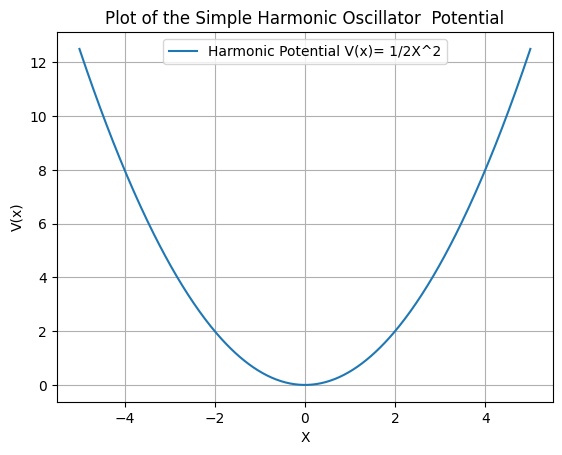

In [11]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

#Defining the Harmonic potential function
def V(x):
    return 0.5*x**2

#Creating an array of x-values over which we will plot the potential
#We choose a range from -5 to 5 with 400 points for a smooth curve
x= np.linspace(-5, 5, 400)

#Compute V(x) for each x-value
Vx = V(x)
plt.plot(x, Vx, label= "Harmonic Potential V(x)= 1/2X^2")

#Label the axes and add a title
plt.xlabel("X")
plt.ylabel("V(x)")
plt.title("Plot of the Simple Harmonic Oscillator  Potential")
plt.grid( True)
plt.legend()
plt.show()




### Solutions of the Schrödinger Equation

<div class="intro">

As suggested above, the solutions of the Quantum Harmonic Oscillator depend on a (<i>vibrational</i>) quantum number $v$.

The energies ($ie$ eigenvalues) are given by

$$ E_v=(v+\frac{1}{2})\hbar\omega$$ with $v=0, 1, 2, ...$ and $\omega=\sqrt{(\frac{k}{m})}$


The corresponding wavefunctions ($ie$ eigenfunctions) are given by

$$\Psi_v=N_vH_ve^{-y^2/2}$$ where $N_v$ is the normalization factor, $H_v$ the <b>Hermite polynomial</b> and $y=(\frac{mk}{\hbar^2})^{1/4}x$.


The <b>Hermite polynomials</b> are defined using a recurrence relation
$$H_{v+1}=2yH_v-2vH_{v-1}$$
with $H_0=1$ and $H_1=2y$.


<div class="exE">

Code a `Hv(v,y)` function returning the evaluation of $v^{th}$ Hermite polynomial, $H_v$ at a given value $y$
</div>

In [2]:
# Task 2: Implementing the Hermite polynomial H_v(y) using recursion

def Hv(v, y):
    """
    Computes the Hermite polynomial H_v(y) using the recurrence relation:
    H0(y) = 1
    H1(y) = 2y
    H_{v+1}(y) = 2y*H_v(y) - 2v*H_{v-1}(y)
    """

# Base cases
    if v == 0:
        return 1
    elif v == 1:
        return 2 * y
    
# Recurrence for v >= 2
    H_prev_prev = 1          # H0
    H_prev = 2 * y           # H1

    for n in range(2, v + 1):
        H_current = 2 * y * H_prev - 2 * (n - 1) * H_prev_prev
 # update for next step
        H_prev_prev = H_prev
        H_prev = H_current

    return H_current

<div class="exE">

Using the `hermite` function from `sympy`, print the first 6 Hermite polynomials and check your code written in the previous cell for a few values of <i>v</i> and <i>y</i>.
The results will be advantageoulsy presented in a table (see example below) beside the expression of the `hermite` polynomial.

<p style="text-align:center;"><img width="320" src = "./MiscImages/tableQHO.jpg"/></p>

</div>

In [15]:
import sympy as sp

from sympy import hermite


# Defining symbolic variable y
y = sp.symbols('y')

print("FIRST 6 HERMITE POLYNOMIALS FROM SYMPY:\n")
for v in range(6):
    print(f"H{v}(y) =", hermite(v, y))


#Comparison Table
# Values to test for Hv(v,y)
test_values = [0, 1, 2]

print("\nCOMPARISON TABLE (OUR Hv FUNCTION VS SYMPY):")
print("v   y     Hv(v,y)            hermite(v,y)")
print("------------------------------------------------")

for v in range(6):  # H0 to H5
    for y_val in test_values:
        our_value = Hv(v, y_val)         # Using our recurrence function
        sympy_value = hermite(v, y_val)  # Using sympy
        print(f"{v}   {y_val}       {our_value}                 {sympy_value}")
    print("------------------------------------------------")




FIRST 6 HERMITE POLYNOMIALS FROM SYMPY:

H0(y) = 1
H1(y) = 2*y
H2(y) = 4*y**2 - 2
H3(y) = 8*y**3 - 12*y
H4(y) = 16*y**4 - 48*y**2 + 12
H5(y) = 32*y**5 - 160*y**3 + 120*y

COMPARISON TABLE (OUR Hv FUNCTION VS SYMPY):
v   y     Hv(v,y)            hermite(v,y)
------------------------------------------------
0   0       1                 1
0   1       1                 1
0   2       1                 1
------------------------------------------------
1   0       0                 0
1   1       2                 2
1   2       4                 4
------------------------------------------------
2   0       -2                 -2
2   1       2                 2
2   2       14                 14
------------------------------------------------
3   0       0                 0
3   1       -4                 -4
3   2       40                 40
------------------------------------------------
4   0       12                 12
4   1       -20                 -20
4   2       76                 76
-

<div class="exE">

Use the previous expression of the Hermite polynomials to verify with `sympy` that the normalization factor $N_v$ 
are given by $N=(\pi ^{1/2} 2^v v!)^{-1/2}$.</div>

In [20]:
import sympy as sp
from sympy import hermite, exp, sqrt, pi, factorial

# Symbolic variable
x = sp.symbols('x', real=True)

# Function to verify Hermite normalization identity
def hermite_identity(v):
    Hv = hermite(v, x)                      # Hermite polynomial H_v(x)
    integrand = Hv**2 * sp.exp(-x**2)       # H_v(x)^2 * e^{-x^2}
    result = sp.integrate(integrand, (x, -sp.oo, sp.oo))
    return sp.simplify(result)

# Example: verify for v = 0
print("v = 0 :", hermite_identity(0))

# Example: verify for v = 1
print("v = 1 :", hermite_identity(1))

# Example: verify for v = 2
print("v = 2 :", hermite_identity(2))

v = 0 : sqrt(pi)
v = 1 : 2*sqrt(pi)
v = 2 : 8*sqrt(pi)


## Wavefunctions

<div class="rqT" title="Directives">
    
From now on, you have to do symbolic algebra with the SymPy library.
</div>

<div class="exE">
Compute the left-hand side of Schrödinger equation to verify that $\Psi_v(x)$ and $E_v$ are eigenfunctions and eigenvalues.

In [17]:
import sympy as sp
from sympy import hermite, sqrt, pi, exp, factorial

# Definining x as a symbolic variable
x = sp.symbols('x', real=True)

# Normalization constant N_v
def Nv(v):
    return 1 / sp.sqrt(sp.sqrt(pi) * (2**v) * factorial(v))

# Wavefunction Ψ_v(x)
def Psi_v(v):
    return Nv(v) * hermite(v, x) * sp.exp(-x**2 / 2)

# Hamiltonian operator H applied to a function f(x)
def H_operator(f):
    kinetic = -sp.diff(f, x, 2) / 2 # -1/2 * d²f/dx²
    potential = (x**2 / 2) * f    # (1/2)x² f(x)
    return kinetic + potential

# Check Schrödinger equation
def check_eigen(v):
    psi = Psi_v(v)
    Hpsi = H_operator(psi)
    Epsi = (v + sp.Rational(1, 2)) * psi  # (v + 1/2) ψv(x)
    return sp.simplify(Hpsi - Epsi)

# Example: check for v = 0
check_eigen(0)
      


0

#### Lowest wavefunctions and their associated energy

<div class="exE">
    
Complete the previous plot by plotting the $\Psi_v(x)$ at level $E_v$.

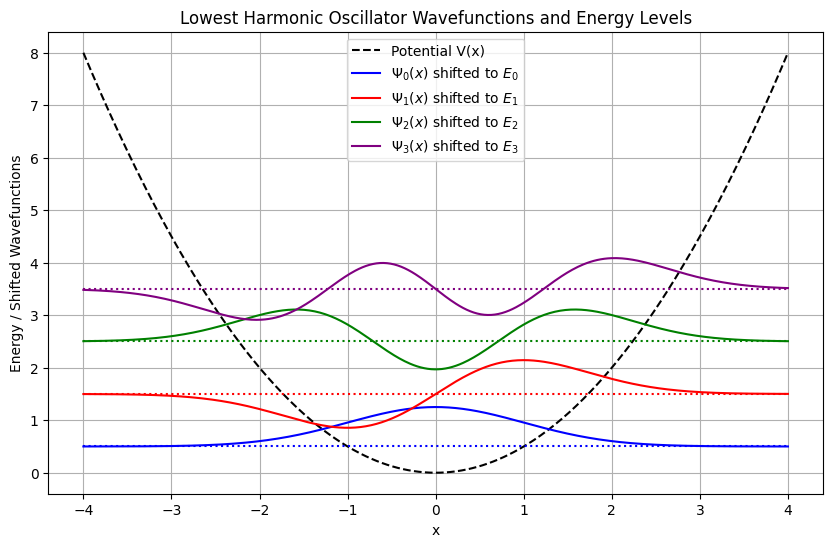

In [4]:

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy import hermite
import math   # 

# Hermite polynomial numeric evaluation

x_sym = sp.symbols('x')

def hermite_numeric(v, x_val):
    """Numerically evaluate Hermite polynomial H_v(x)."""
    H_v_sym = hermite(v, x_sym)
    H_v_func = sp.lambdify(x_sym, H_v_sym, 'numpy')
    return H_v_func(x_val)

# Correcting numerical normalization constant (pure NumPy + math)

def Nv(v):
    return 1.0 / np.sqrt(np.sqrt(np.pi) * (2**v) * math.factorial(v))

# Numerical wavefunction
def Psi_v(v, x):
    return Nv(v) * hermite_numeric(v, x) * np.exp(-x**2 / 2)

# Plotting the lowest wavefunctions

x_vals = np.linspace(-4, 4, 400)

plt.figure(figsize=(10, 6))

# Potential V(x)
V = 0.5 * x_vals**2
plt.plot(x_vals, V, 'k--', label="Potential V(x)")

colors = ['blue', 'red', 'green', 'purple']

for v in range(4):
    psi_vals = Psi_v(v, x_vals)

    E_v = v + 0.5
    psi_shifted = psi_vals + E_v

    plt.plot(x_vals, psi_shifted,
             color=colors[v],
             label=rf"$\Psi_{v}(x)$ shifted to $E_{v}$")

    plt.hlines(E_v, -4, 4, colors=colors[v], linestyles=':')

plt.title("Lowest Harmonic Oscillator Wavefunctions and Energy Levels")
plt.xlabel("x")
plt.ylabel("Energy / Shifted Wavefunctions")
plt.grid(True)
plt.legend()
plt.show()


### Expectations values

<div class="intro">

The expectation value of an observable $\Omega$ is given by
$$<\Omega >=\int_{-\infty}^{+\infty}{\Psi^*_v \Omega \Psi_v dx}$$   

<div class="exE">    
Show that, with the values chosen for the constants, $<x^2>=v+\frac{1}{2}$.

In [5]:

import numpy as np

# Defining the  integration range
x_vals = np.linspace(-6, 6, 2000)

def expectation(v):
    """Compute <x> and <x^2> for wavefunction Psi_v(x)."""
    
    psi = Psi_v(v, x_vals)
    prob_density = psi * psi  # |Psi|^2

    # <x>
    exp_x = np.trapz(prob_density * x_vals, x_vals)

    # <x^2>
    exp_x2 = np.trapz(prob_density * x_vals**2, x_vals)

    return exp_x, exp_x2

# Compute for v = 0, 1, 2, 3
for v in range(4):
    ex, ex2 = expectation(v)
    print(f"v = {v}")
    print(f"<x>   ≈ {ex:.6f}   (theoretical: 0)")
    print(f"<x^2> ≈ {ex2:.6f} (theoretical: {v + 0.5})")
    print("------------------------------------------------")


v = 0
<x>   ≈ 0.000000   (theoretical: 0)
<x^2> ≈ 0.500000 (theoretical: 0.5)
------------------------------------------------
v = 1
<x>   ≈ 0.000000   (theoretical: 0)
<x^2> ≈ 1.500000 (theoretical: 1.5)
------------------------------------------------
v = 2
<x>   ≈ 0.000000   (theoretical: 0)
<x^2> ≈ 2.500000 (theoretical: 2.5)
------------------------------------------------
v = 3
<x>   ≈ 0.000000   (theoretical: 0)
<x^2> ≈ 3.500000 (theoretical: 3.5)
------------------------------------------------


C:\Users\malih  ezekiel lah\AppData\Local\Temp\ipykernel_10520\734927426.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  exp_x = np.trapz(prob_density * x_vals, x_vals)
C:\Users\malih  ezekiel lah\AppData\Local\Temp\ipykernel_10520\734927426.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  exp_x2 = np.trapz(prob_density * x_vals**2, x_vals)


<div class="exE">
Search the nodes of the wavefunctions (<i>ie</i> solve $H_v(y)=0$) for different values of $v$ and make a plot of these nodes.

</div>

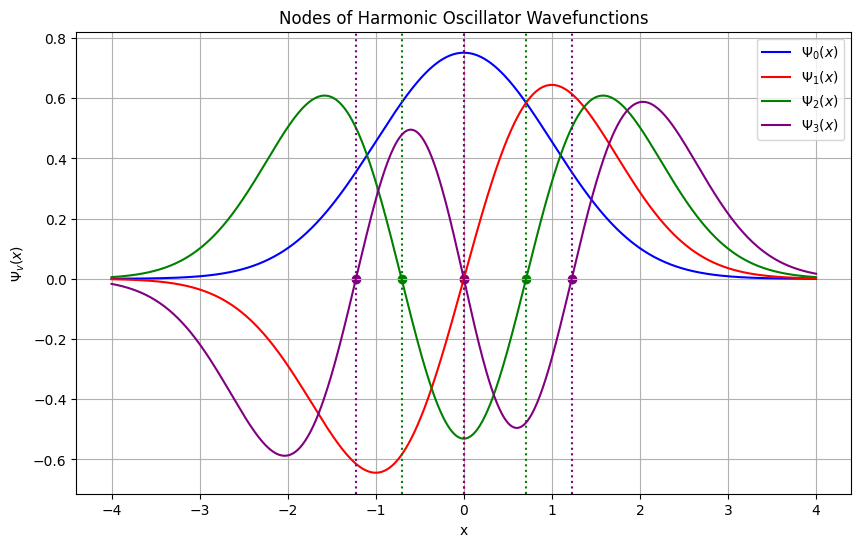

Nodes for v=0: []
Nodes for v=1: [0.0]
Nodes for v=2: [-0.7071067811865476, 0.7071067811865476]
Nodes for v=3: [-1.224744871391589, 0.0, 1.224744871391589]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy import hermite
import math

x = sp.symbols('x')

def hermite_roots(v):
    """Return the roots (nodes) of Hermite polynomial H_v(x)."""
    if v == 0:
        return []   # H0(x) = 1 → no roots
    H = hermite(v, x)
    roots = sp.nroots(H)
    roots = sorted([float(r) for r in roots])
    return roots

# Plotting Psi_v with node markers
x_vals = np.linspace(-4, 4, 800)

plt.figure(figsize=(10, 6))

colors = ['blue', 'red', 'green', 'purple']

for v in range(4):
    psi_vals = Psi_v(v, x_vals)

    plt.plot(x_vals, psi_vals, color=colors[v], label=rf"$\Psi_{v}(x)$")

# Mark nodes
    nodes = hermite_roots(v)
    for node in nodes:
        plt.axvline(node, color=colors[v], linestyle=':')
        plt.scatter(node, 0, color=colors[v])

plt.title("Nodes of Harmonic Oscillator Wavefunctions")
plt.xlabel("x")
plt.ylabel(r"$\Psi_v(x)$")
plt.grid(True)
plt.legend()
plt.show()

# Printing node positions clearly
for v in range(4):
    print(f"Nodes for v={v}: {hermite_roots(v)}")




# End

In [3]:
vID.end(cwd0)

**End at:** Saturday 09 September 2023, 11:08:08  
**Duration:** 00:00:31 233ms

<p style="text-align: center"><img width="800px" src="./config/svg/logoEnd.svg" style="margin-left:auto; margin-right:auto"/></p>